# COVID-19 Time-Series Analysis in R

This notebook analyses the Johns Hopkins CSSE global confirmed-cases series in R: load the data,
keep China, compute daily cases per province, plot them, examine inter-province correlations, and
run PCA.

### Setup

In [1]:
# default plot size for the wide figures
options(repr.plot.width = 12, repr.plot.height = 7)
library(pheatmap)
library(scatterplot3d)

## Load data

In [2]:
df <- read.csv("time_series_covid19_confirmed_global.csv", check.names = FALSE)
head(df, 2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,⋯,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,⋯,74,84,94,110,110,120,170,174,237,273
2,,Albania,41.1533,20.1683,0,0,0,0,0,0,⋯,123,146,174,186,197,212,223,243,259,277


## Get only China's data
Data shows daily accumulation of confirmed cases from 01/22/2020 to 04/02/2020.

In [3]:
China <- df[df[["Country/Region"]] == "China", ]
head(China, 2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,⋯,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
50,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,⋯,990,990,990,990,990,990,990,990,990,990
51,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,⋯,558,561,566,569,573,577,577,580,580,582


## Discard Country/Region, Lat and Long columns

In [4]:
China_2 <- China[, !(names(China) %in% c("Country/Region", "Lat", "Long"))]
head(China_2)

,Province/State,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,⋯,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
50,Anhui,1,9,15,39,60,70,106,152,200,⋯,990,990,990,990,990,990,990,990,990,990
51,Beijing,14,22,36,41,68,80,91,111,114,⋯,558,561,566,569,573,577,577,580,580,582
52,Chongqing,6,9,27,57,75,110,132,147,182,⋯,578,578,578,578,578,579,579,579,579,579
53,Fujian,1,5,10,18,35,59,80,84,101,⋯,318,322,328,331,337,338,340,343,345,345
54,Gansu,0,2,2,4,7,14,19,24,26,⋯,136,136,136,136,136,138,138,138,138,138
55,Guangdong,26,32,53,78,111,151,207,277,354,⋯,1428,1433,1448,1456,1467,1475,1484,1494,1501,1507


## Compute daily confirmed cases by province
The data is cumulative, so the daily count is the difference between consecutive days.

In [5]:
cases_mat <- as.matrix(China_2[, -1])      # provinces x days (cumulative)
N <- ncol(cases_mat)
X1 <- cases_mat[, 1:(N - 1)]               # day 1 .. day N-1
X2 <- cases_mat[, 2:N]                      # day 2 .. day N
daily_cases <- X2 - X1                       # day_i - day_(i-1)
print(daily_cases)

   1/23/20 1/24/20 1/25/20 1/26/20 1/27/20 1/28/20 1/29/20 1/30/20 1/31/20
50       8       6      24      21      10      36      46      48      37
51       8      14       5      27      12      11      20       3      25
52       3      18      30      18      35      22      15      35      29
53       4       5       8      17      24      21       4      17      19
54       2       0       2       3       7       5       5       2       3
55       6      21      25      33      40      56      70      77      82
56       3      18       0      13      10       5       7      20       9
57       2       0       1       1       2       2       0       3      17
58       1       3      11       3      11       7       3       3       6
59       0       1       6       5       5      15      15      17      17
60       2       2       5       6       6      12       5       6      15
61       0       4      23      51      45      40      38      72      74
62       2       0       

Save the daily cases in a new data frame (`China_dc`). The first day keeps its cumulative
value because there is no earlier day to subtract.

In [6]:
day_cols   <- names(China_2)[-1]
day_1      <- day_cols[1]
other_days <- day_cols[-1]

daily_df <- as.data.frame(daily_cases, check.names = FALSE)
colnames(daily_df) <- other_days

China_dc <- cbind(
  data.frame(Province = China_2[["Province/State"]], check.names = FALSE),
  China_2[day_1],          # cumulative cases on the first day
  daily_df                  # daily increments afterwards
)
head(China_dc, 3)

,Province,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,⋯,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
50,Anhui,1,8,6,24,21,10,36,46,48,⋯,0,0,0,0,0,0,0,0,0,0
51,Beijing,14,8,14,5,27,12,11,20,3,⋯,21,3,5,3,4,4,0,3,0,2
52,Chongqing,6,3,18,30,18,35,22,15,35,⋯,0,0,0,0,0,1,0,0,0,0


## Reset index to start from 0

In [7]:
rownames(China_dc) <- NULL
head(China_dc)

,Province,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,⋯,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,Anhui,1,8,6,24,21,10,36,46,48,⋯,0,0,0,0,0,0,0,0,0,0
2,Beijing,14,8,14,5,27,12,11,20,3,⋯,21,3,5,3,4,4,0,3,0,2
3,Chongqing,6,3,18,30,18,35,22,15,35,⋯,0,0,0,0,0,1,0,0,0,0
4,Fujian,1,4,5,8,17,24,21,4,17,⋯,5,4,6,3,6,1,2,3,2,0
5,Gansu,0,2,0,2,3,7,5,5,2,⋯,0,0,0,0,0,2,0,0,0,0
6,Guangdong,26,6,21,25,33,40,56,70,77,⋯,13,5,15,8,11,8,9,10,7,6


## Transpose: provinces as columns and days as rows

In [8]:
prov_names <- China_dc$Province
cases_only <- China_dc[, -1]                 # day columns only
China_dc_t <- as.data.frame(t(cases_only), check.names = FALSE)
colnames(China_dc_t) <- prov_names
rownames(China_dc_t) <- NULL
head(China_dc_t)

,Anhui,Beijing,Chongqing,Fujian,Gansu,Guangdong,Guangxi,Guizhou,Hainan,Hebei,⋯,Shaanxi,Shandong,Shanghai,Shanxi,Sichuan,Tianjin,Tibet,Xinjiang,Yunnan,Zhejiang
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,14,6,1,0,26,2,1,4,1,⋯,0,2,9,1,5,4,0,0,1,10
2,8,8,3,4,2,6,3,2,1,0,⋯,3,4,7,0,3,0,0,2,1,17
3,6,14,18,5,0,21,18,0,3,1,⋯,2,9,4,0,7,4,0,0,3,16
4,24,5,30,8,2,25,0,1,11,6,⋯,10,12,13,5,13,2,0,1,6,19
5,21,27,18,17,3,33,13,1,3,5,⋯,7,19,7,3,16,4,0,1,5,42
6,10,12,35,24,7,40,10,2,11,5,⋯,13,29,13,4,25,9,0,1,10,24


## Display daily confirmed cases

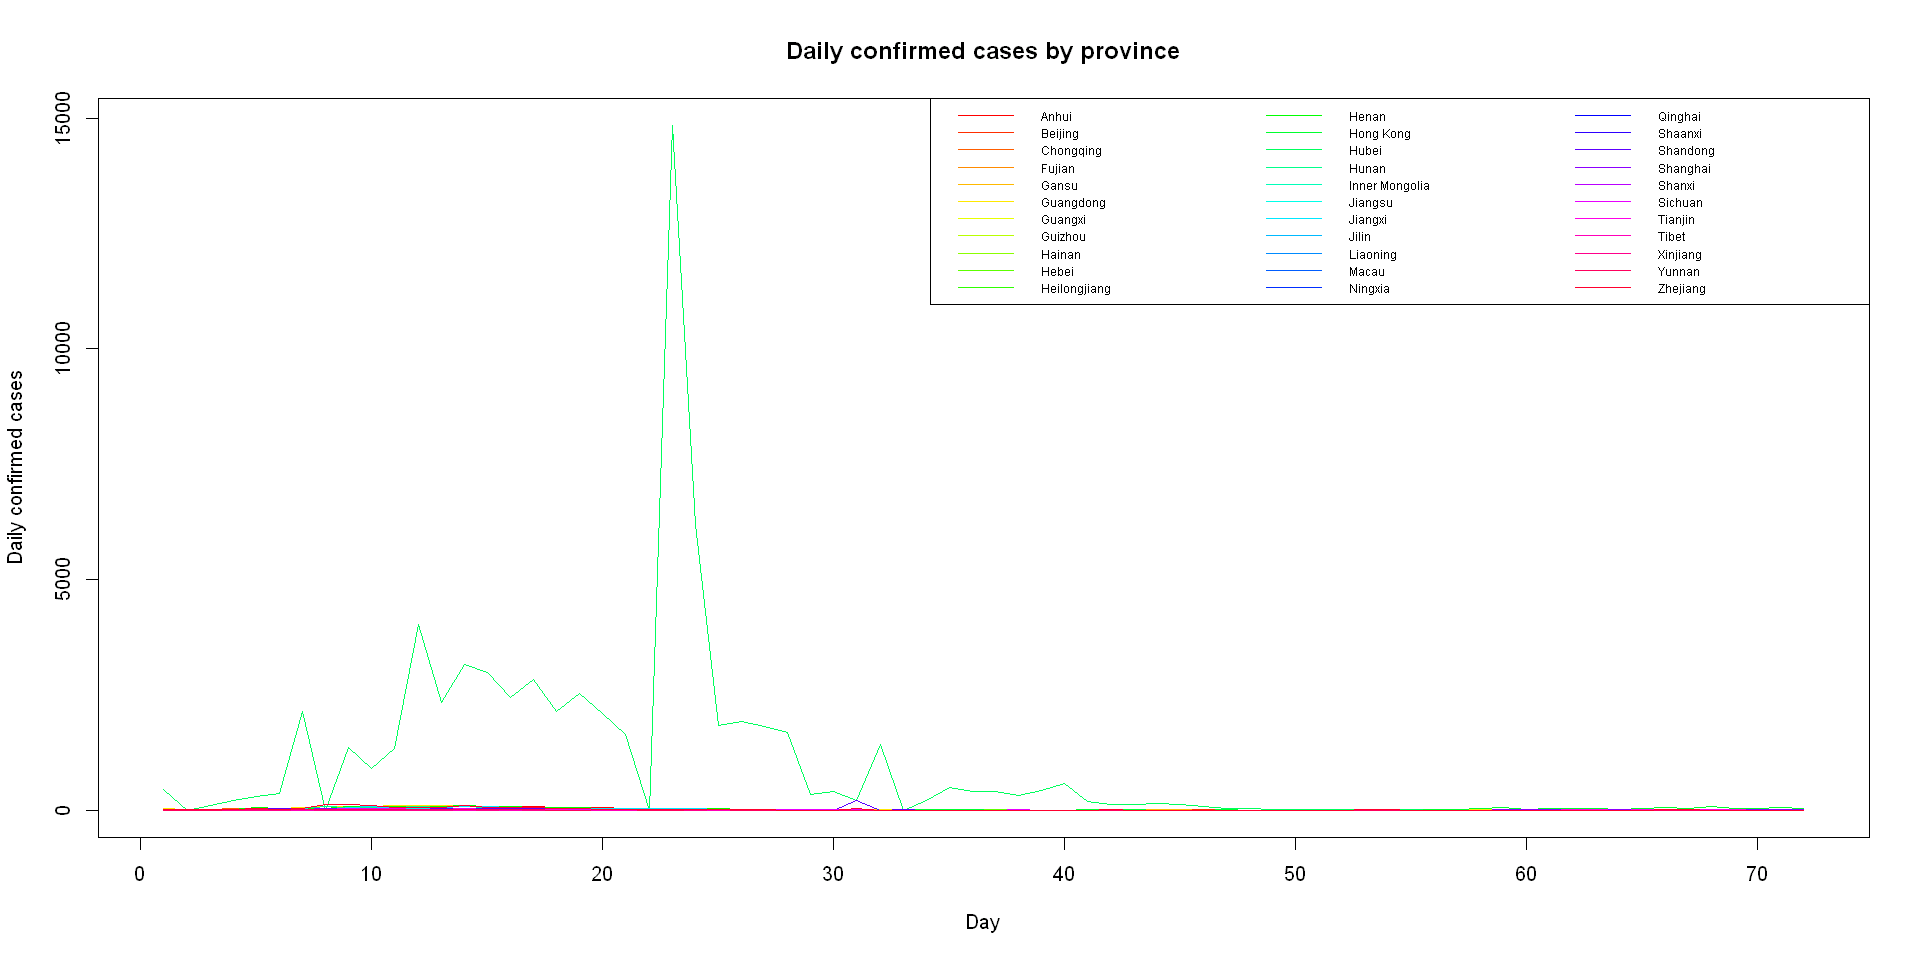

In [9]:
options(repr.plot.width = 16, repr.plot.height = 8)
mat <- as.matrix(China_dc_t)
matplot(mat, type = "l", lty = 1, col = rainbow(ncol(mat)),
        xlab = "Day", ylab = "Daily confirmed cases",
        main = "Daily confirmed cases by province")
legend("topright", legend = colnames(mat), col = rainbow(ncol(mat)),
       lty = 1, cex = 0.6, ncol = 3)

Hubei is a clear outlier (huge number of cases), so discard it.

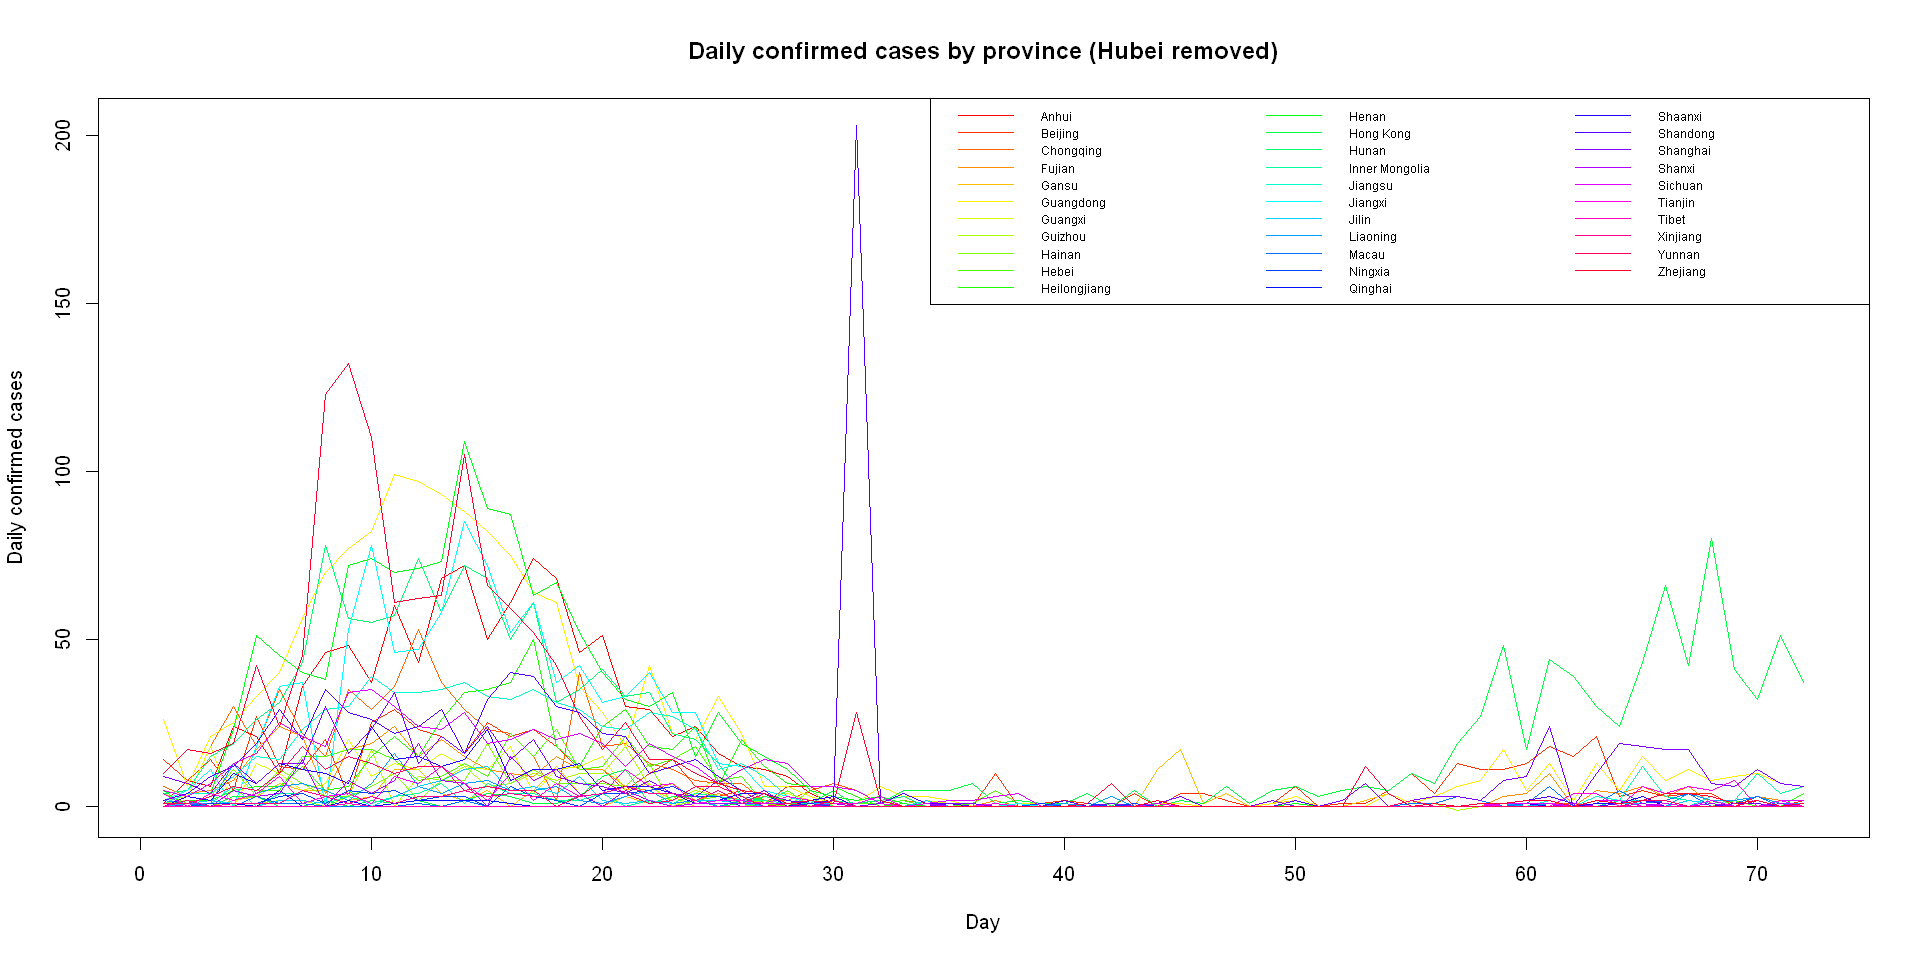

In [10]:
China_4 <- China_dc_t[, !(names(China_dc_t) %in% "Hubei")]
mat4 <- as.matrix(China_4)
matplot(mat4, type = "l", lty = 1, col = rainbow(ncol(mat4)),
        xlab = "Day", ylab = "Daily confirmed cases",
        main = "Daily confirmed cases by province (Hubei removed)")
legend("topright", legend = colnames(mat4), col = rainbow(ncol(mat4)),
       lty = 1, cex = 0.6, ncol = 3)

## Correlation between provinces (Pearson)

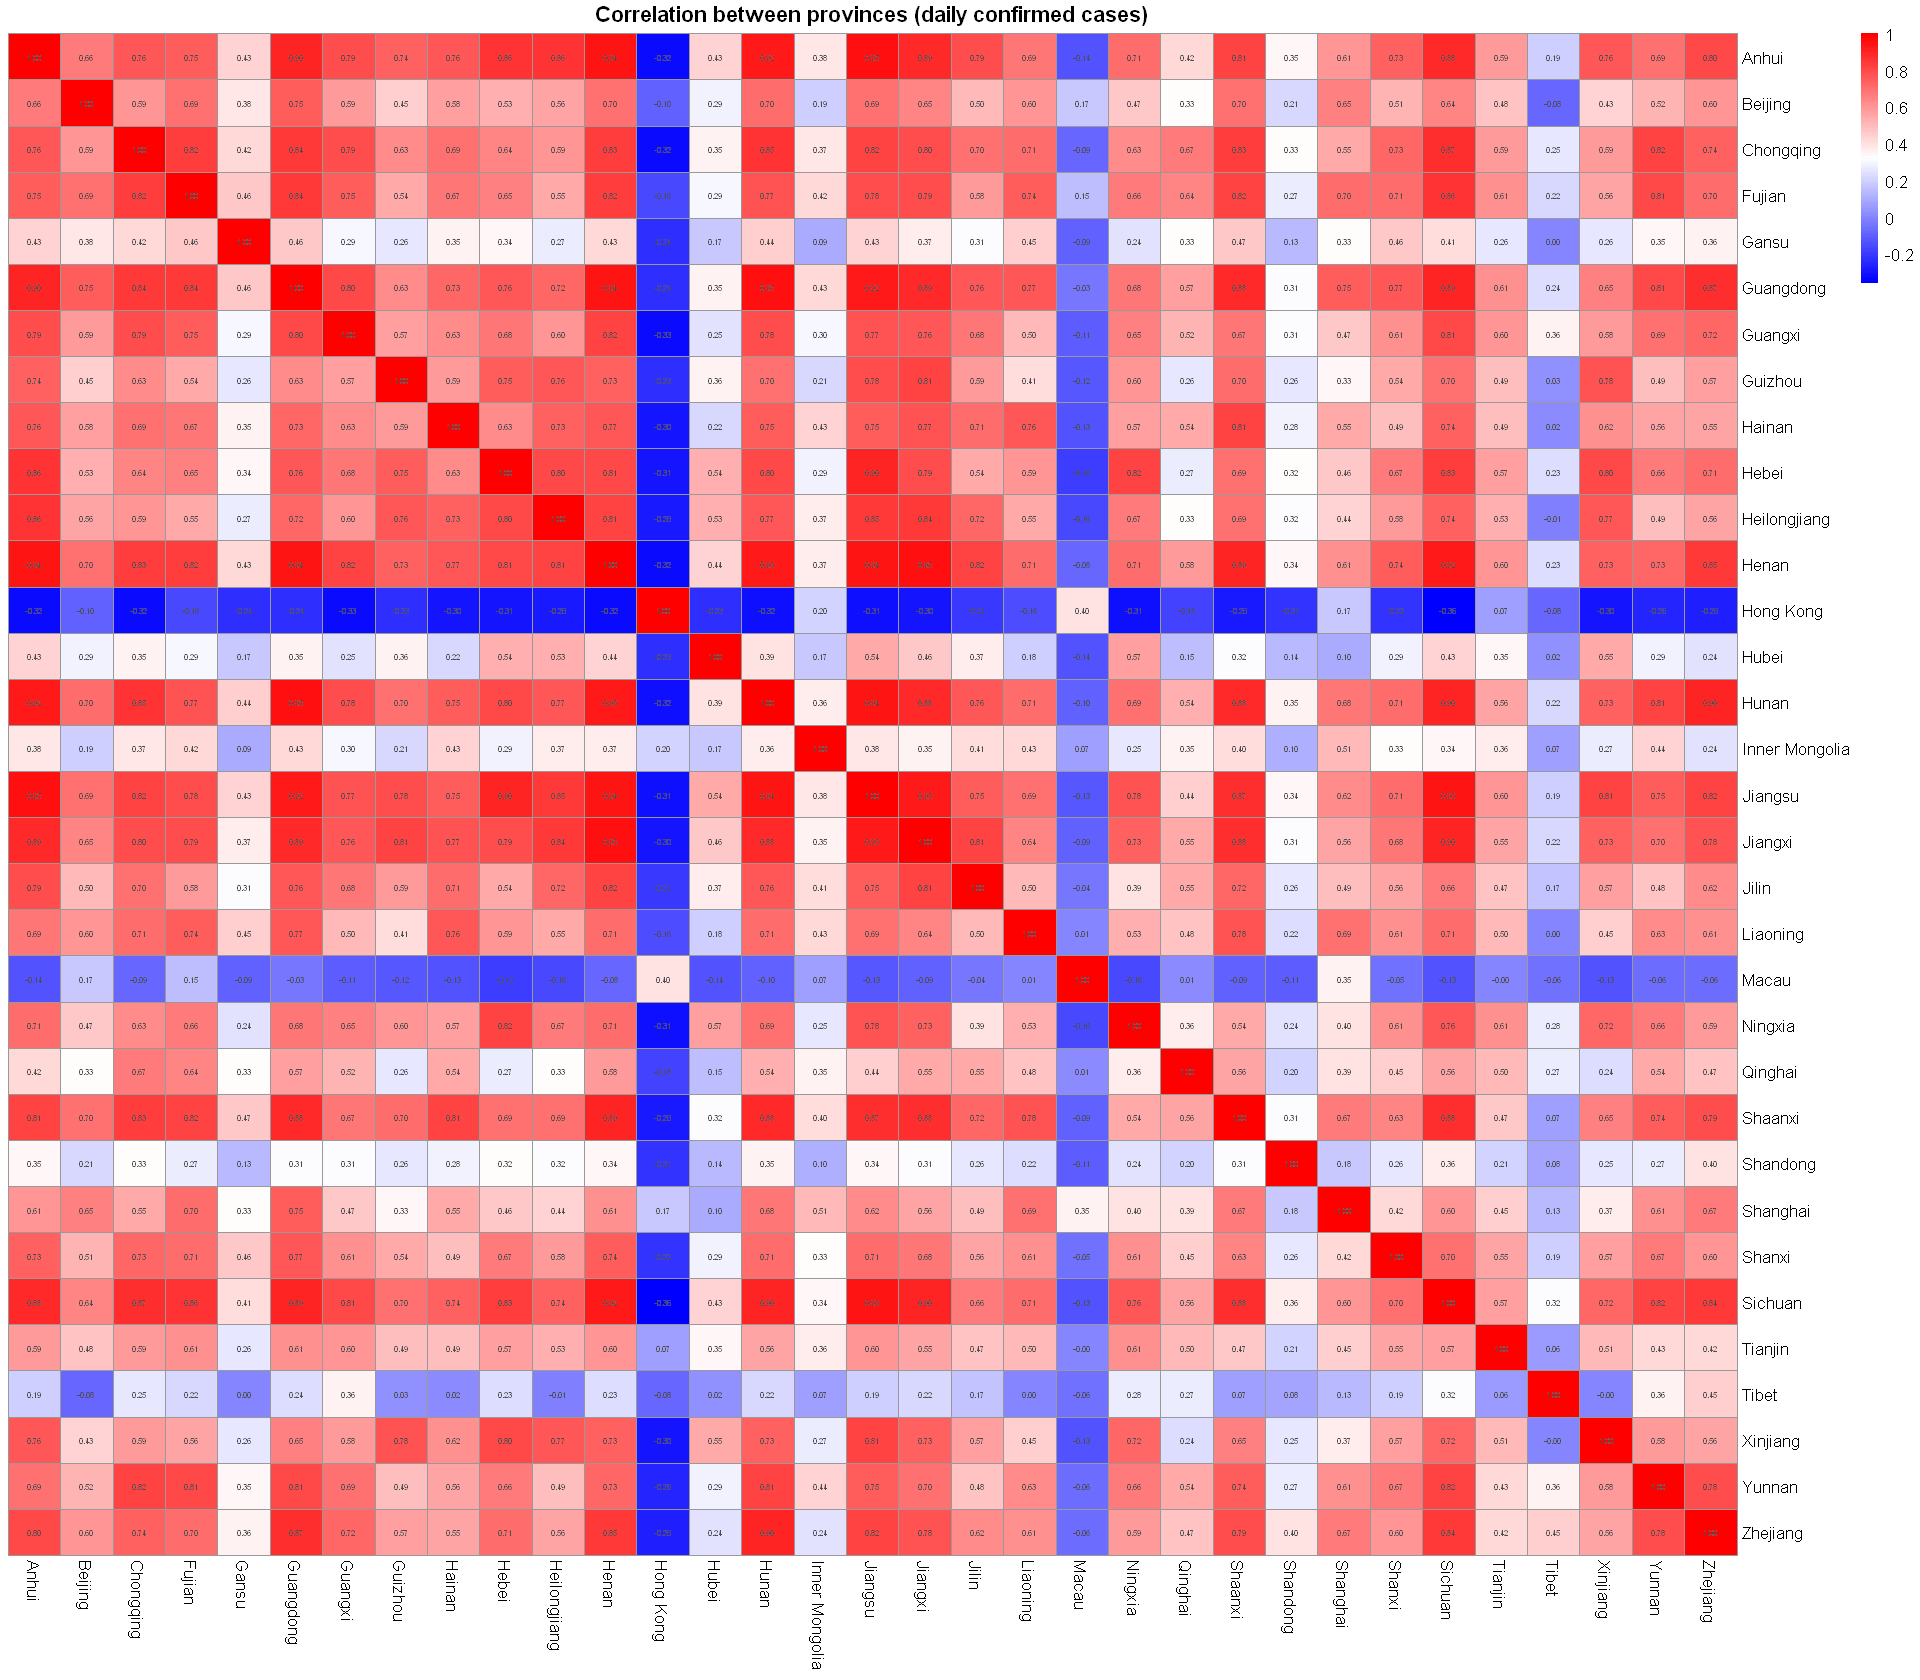

In [11]:
options(repr.plot.width = 16, repr.plot.height = 14)
corr_mat <- cor(China_dc_t)
pheatmap(corr_mat,
         display_numbers = TRUE, number_format = "%.2f", fontsize_number = 5,
         cluster_rows = FALSE, cluster_cols = FALSE,
         color = colorRampPalette(c("blue", "white", "red"))(100),
         main = "Correlation between provinces (daily confirmed cases)")

## Sort the correlations
Flatten the absolute correlation matrix, drop the self-correlations on the diagonal, and remove the
symmetric duplicates to list the most correlated province pairs.

In [12]:
corr_abs <- abs(cor(China_dc_t))
pairs <- as.data.frame(as.table(corr_abs), stringsAsFactors = FALSE)
pairs <- pairs[pairs$Var1 != pairs$Var2, ]            # drop diagonal
pairs <- pairs[order(-pairs$Freq), ]
pairs <- pairs[seq(1, nrow(pairs), by = 2), ]          # drop symmetric duplicates
colnames(pairs) <- c("Province_A", "Province_B", "abs_correlation")
head(pairs, 16)

,Province_A,Province_B,abs_correlation
,<chr>,<chr>,<dbl>
17,Jiangsu,Anhui,0.9488838
180,Hunan,Guangdong,0.9471269
381,Jiangxi,Henan,0.9460755
479,Jiangsu,Hunan,0.9437320
380,Jiangsu,Henan,0.9417998
177,Henan,Guangdong,0.9395862
12,Henan,Anhui,0.9365651
556,Sichuan,Jiangsu,0.9325644
378,Hunan,Henan,0.9299921


## PCA
Treat the days as the variables and the provinces as the instances, then keep the first three
principal components.

In [13]:
X <- as.matrix(China_dc[, day_cols])     # 33 provinces x N days
cat("X shape:", dim(X), "\n")
print(X[1:3, 1:6])

X shape: 33 72 


     1/22/20 1/23/20 1/24/20 1/25/20 1/26/20 1/27/20
[1,]       1       8       6      24      21      10
[2,]      14       8      14       5      27      12
[3,]       6       3      18      30      18      35


In [14]:
pca <- prcomp(X, center = TRUE, scale. = FALSE)
X_reduced <- pca$x[, 1:3]
dim(X_reduced)

[1] 33  3

### Explained variances, cumulative variances and their ratios

In [15]:
exp_var       <- (pca$sdev^2 / sum(pca$sdev^2))[1:3]
cumul_var     <- cumsum(exp_var)
exp_var_ratio <- exp_var

cat("Explained variances:    ", exp_var, "\n")
cat("Cumulative variances:   ", cumul_var, "\n")
cat("Ratio explained variances:", exp_var_ratio, "\n")

Explained variances:     0.9991616 0.0005164877 0.0001183912 


Cumulative variances:    0.9991616 0.9996781 0.9997965 


Ratio explained variances: 0.9991616 0.0005164877 0.0001183912 


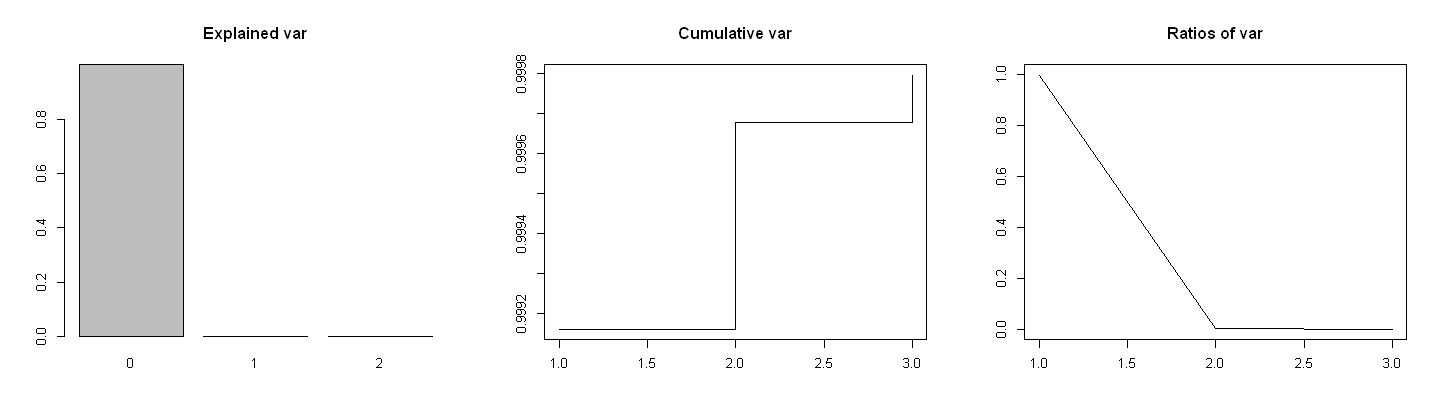

In [16]:
options(repr.plot.width = 12, repr.plot.height = 3.5)
par(mfrow = c(1, 3))
barplot(exp_var, names.arg = 0:2, main = "Explained var")
plot(cumul_var, type = "s", main = "Cumulative var", xlab = "", ylab = "")
plot(exp_var_ratio, type = "l", main = "Ratios of var", xlab = "", ylab = "")
par(mfrow = c(1, 1))

### Save the PC values in a data frame

In [17]:
X_reduced_df <- as.data.frame(X_reduced)
colnames(X_reduced_df) <- c("w1", "w2", "w3")
head(X_reduced_df, 5)

,w1,w2,w3
,<dbl>,<dbl>,<dbl>
1,-496.9774,101.301488,11.812384
2,-572.3131,-8.321902,8.183773
3,-556.3710,24.567849,4.004067
4,-586.9118,-19.065950,6.718658
5,-607.2526,-53.302153,2.534793


### Scatter of the data using the first three PCs

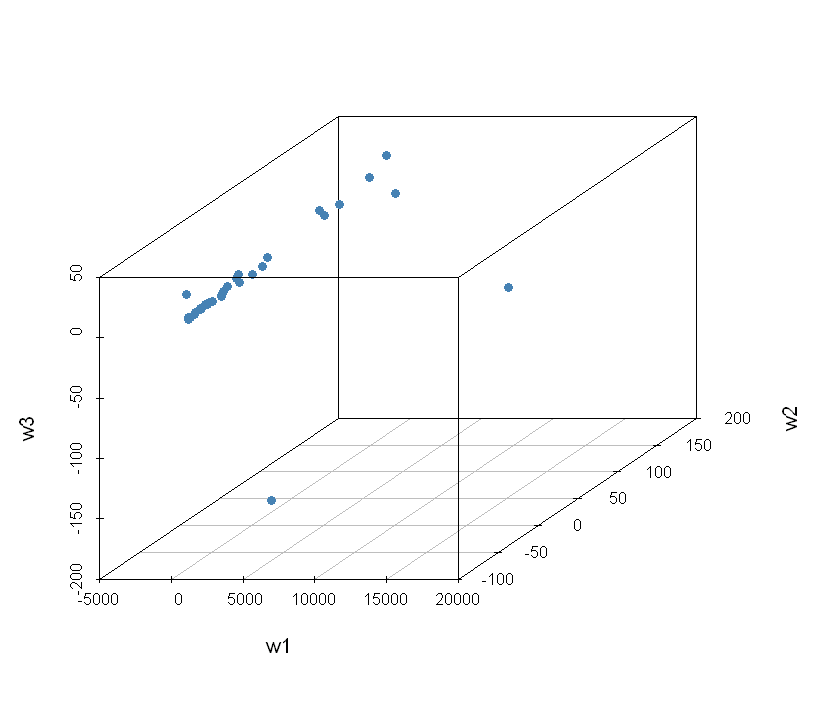

In [18]:
options(repr.plot.width = 7, repr.plot.height = 6)
scatterplot3d(X_reduced_df$w1, X_reduced_df$w2, X_reduced_df$w3,
              xlab = "w1", ylab = "w2", zlab = "w3",
              pch = 16, color = "steelblue")

### Scatter of the data using two of the PCs

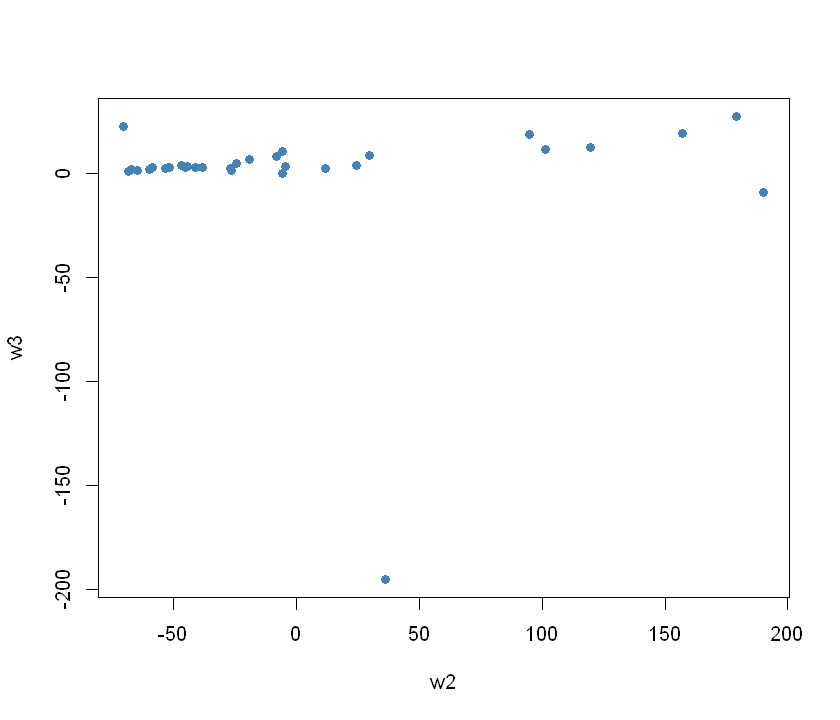

In [19]:
plot(X_reduced_df$w2, X_reduced_df$w3,
     xlab = "w2", ylab = "w3", pch = 16, col = "steelblue")